# AI School · Epoch 2 · Checkpoint 2.1
## Linear Regression on Bike-Sharing Demand

---

**Total Points:** 100 points (main) + 10 bonus points  
**Minimum Required:** 85 / 100

**Dataset:** Bike Sharing Demand — loaded directly from Hugging Face 🤗  
**Goal:** Build, evaluate, and interpret Linear Regression and its regularised variants (Ridge & Lasso) on a real-world regression task.

**Submission:** Push your `.ipynb` to GitHub and submit the repo link in the form: https://forms.gle/r3JLHDKfxR5XAcdr5.

> *Take your time on the reflection questions — they matter just as much as the code.*

---

## Part 0 · Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import learning_curve, cross_val_score

sns.set_theme(style="whitegrid")
%matplotlib inline

---

## Part 1 · Conceptual Warm-Up  *(15 points)*

Before touching any code, take a moment to reflect.  
Write your answers in the Markdown cells provided — a few clear sentences per question is enough.

### Q1 · What is Hugging Face? *(5 points)*

In your own words, answer the following:

1. What is Hugging Face and what role does it play in the modern ML ecosystem?
2. Beyond hosting datasets, name **three** functionalities it offers.
3. Why is using a centralised hub like HF better than emailing CSV files around a team?

✏️ *Write your answer below:*

**1. What is Hugging Face?**

Hugging Face is an AI platform and open source community that hosts pretrained models, datasets, and ML tools. 
In the modern ML ecosystem it acts as a central hub a "GitHub for AI" where practitioners can share and reuse work.

**2. Three functionalities beyond hosting datasets:**
- **Model Hub:** thousands of pre-trained models (transformers, diffusion, etc.) ready for fine-tuning or inference.
- **Spaces:** free hosting for interactive ML demos built with Gradio or Streamlit.
- **Inference API:** a managed API to run models in the cloud without any infrastructure setup.

**3. Why a centralised hub beats emailing CSV files:**
A hub like Hugging Face enforces versioning so every team member works from the exact same snapshot of the data. 
Access controls, download counts, and dataset cards add transparency and reproducibility that a shared email attachment can never provide.

### Q2 · Log Transformation vs. Scalers *(5 points)*

In the preprocessing notebook, the target `cnt` was replaced with `log_cnt = log1p(cnt)`.

1. What is a log transformation, and what property of a distribution does it correct?
2. When should you apply it (give a concrete rule of thumb)?
3. How is it **fundamentally different** from StandardScaler or MinMaxScaler?  
   *(Hint: think about what each one changes — the shape of the distribution or just its location/scale.)*

✏️ *Write your answer below:*

**1. What is a log transformation and what does it correct?**

A log transformation replaces each value *x* with log(1 + x) (`log1p`). It compresses the right tail of a skewed distribution, 
pulling large values closer to the centre so the distribution becomes more symmetric (closer to Gaussian).

**2. Rule of thumb for when to apply it:**
Apply a log transform when the target (or a feature) is right-skewed concretely when its skewness coefficient is > 1 or 
when a histogram shows a long right tail. Count variables (like bike rentals) almost always benefit from it.

**3. How is it fundamentally different from StandardScaler / MinMaxScaler?**
- **StandardScaler / MinMaxScaler** only shift and rescale the distribution (change its *location* and *scale*)  they do **not** change its *shape*.
- A **log transformation** actually changes the *shape* of the distribution, correcting skewness. 
After log-transforming, StandardScaler can then be applied on top to standardise scale.

### Q3 · Personal Reflection *(5 points)*

Look back at the two EDA & preprocessing notebooks.

1. Which preprocessing step was the most **novel** to you, and why?
2. Were there any decisions you would have made differently? Justify your answer.

✏️ *Write your answer below:*

**1. Most novel preprocessing step:**

The cyclical encoding of the `hr` feature (sin/cos) was the most novel step. 
Without it, a model would treat hour 23 and hour 0 as maximally different, when they are actually adjacent in time. 
Encoding periodicity explicitly prevents that false ordinal gap.

**2. Would I have made any different decisions?**

I would have considered keeping `mnth` encoded cyclically (like `hr`) instead of dropping it entirely, 
since month captures seasonality at a finer granularity than `season`. 
However, the Cramér's V analysis showed very strong association with `season` (V ≈ 1), 
so dropping it to avoid multicollinearity and reduce dimensionality is well justified.

---

## Part 2 · Loading Data from Hugging Face  *(10 points)*

The dataset has already been cleaned, preprocessed, and uploaded to Hugging Face for you.  
Your first task is to load it — this is a skill you will use in every future project.

### Exo 1 · Install & import the HF library *(2 points)*

Run the cell below to install `datasets` (already done in Colab — just make sure it works).

In [4]:
# !pip install datasets -q   # uncomment if needed
from datasets import load_dataset   

c:\Users\tassili\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Exo 2 · Load the dataset *(4 points)*

Use `load_dataset` to load `"b-fatma/bike-sharing-federated"`.  
The dataset has two splits: `"train"` and `"test"`.

Convert both splits to pandas DataFrames and store them in:  
- `train_df`, `test_df`

Then **print all column names** and the shape of each DataFrame.  
Identify which column is the target (it will be the one that is not a feature).

> 💡 **Hint:** The feature columns you expect are the ones produced by the preprocessing notebook  
> (`yr`, `workingday`, `atemp`, `hum`, `windspeed`, `hr_sin`, `hr_cos`, and the one-hot encoded  
> `season_*` and `weathersit_*` columns). Any extra column is the target.

In [5]:
# load the dataset from HF
dataset = load_dataset('b-fatma/bike-sharing-federated')
print(dataset)

c:\Users\tassili\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tassili\.cache\huggingface\hub\datasets--b-fatma--bike-sharing-federated. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 3476/3476 [00:00<00:00, 241733.00 exa

DatasetDict({
    train: Dataset({
        features: ['yr', 'workingday', 'atemp', 'hum', 'windspeed', 'hr_sin', 'hr_cos', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'cnt_log'],
        num_rows: 13900
    })
    test: Dataset({
        features: ['yr', 'workingday', 'atemp', 'hum', 'windspeed', 'hr_sin', 'hr_cos', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'cnt_log'],
        num_rows: 3476
    })
})


In [6]:
# convert to DataFrames and print shapes
train_df = dataset['train'].to_pandas()
test_df  = dataset['test'].to_pandas()

print('Train columns:', train_df.columns.tolist())
print('Train shape :', train_df.shape)
print('Test  shape :', test_df.shape)

Train columns: ['yr', 'workingday', 'atemp', 'hum', 'windspeed', 'hr_sin', 'hr_cos', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'cnt_log']
Train shape : (13900, 13)
Test  shape : (3476, 13)


### Exo 3 · Separate features and target *(4 points)*

After inspecting the columns in Exo 2, identify the **target column** (the log-transformed count).  
Store its name in a variable called `TARGET`.

Split each DataFrame into `X` (features) and `y` (target):
- `X_train`, `y_train`
- `X_test`, `y_test`

Print `TARGET` and the shape of `X_train`.

In [8]:
# Inspect all columns to identify the target
print(train_df.columns.tolist())

['yr', 'workingday', 'atemp', 'hum', 'windspeed', 'hr_sin', 'hr_cos', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'cnt_log']


In [11]:
# Set TARGET to the column name you identified above, then split
TARGET = 'cnt_log'  # replace ??? with the actual column name

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET].values

X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET].values

print(f'Target column: {TARGET}')
print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')

Target column: cnt_log
X_train: (13900, 12)  |  y_train: (13900,)


---

## Part 3 · Baseline Linear Regression  *(30 points)*

### Exo 4 · Fit a Linear Regression model *(5 points)*

Using **scikit-learn**:
1. Instantiate a `LinearRegression` model.
2. Fit it on `X_train`, `y_train`.
3. Generate predictions on both the **train** and **test** sets.

Store predictions as `y_train_pred` and `y_test_pred`.

In [12]:
# fit LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
# predict on train and test
y_train_pred = lr.predict(X_train)
y_test_pred  = lr.predict(X_test)

### Exo 5 · Compute & interpret metrics *(8 points)*

Compute the following metrics for **both** train and test sets and display them in a clean DataFrame:

| Set   | MSE | RMSE | MAE | R² |
|-------|-----|------|-----|----|

Then answer (in Markdown below the table):
- What does each metric tell you?
- Is the model underfitting, overfitting, or well-fitted? How can you tell from these numbers?

In [14]:
# compute metrics
def compute_metrics(y_true, y_pred, label):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'Set': label, 'MSE': round(mse,4), 'RMSE': round(rmse,4),
            'MAE': round(mae,4), 'R²': round(r2,4)}

metrics_table = pd.DataFrame([
    compute_metrics(y_train, y_train_pred, 'Train'),
    compute_metrics(y_test,  y_test_pred,  'Test'),
])
metrics_table.set_index('Set')

,MSE,RMSE,MAE,R²
Set,,,,
Train,0.7538,0.8682,0.6877,0.6256
Test,0.7510,0.8666,0.6807,0.6243


✏️ *Interpret the metrics here:*

**Metric interpretation:**

- **MSE** (Mean Squared Error): average squared error; penalises large mistakes heavily. Lower is better.
- **RMSE** (Root MSE): in the same units as the target (log-scale here); easier to read than MSE.
- **MAE** (Mean Absolute Error): average absolute deviation; more robust to outliers than RMSE.
- **R²**: proportion of variance explained; 1.0 = perfect, 0 = predicting the mean only.

**Fitting diagnosis:** If Train R² and Test R² are both moderate and close to each other, the model is well-fitted. 
A large gap (Train R² >> Test R²) would indicate overfitting; both low would indicate underfitting. 
Linear regression on this dataset typically shows slight underfitting because bike demand has complex non-linear patterns.

### Exo 6 · Residual plot *(7 points)*

A **residual** is the difference between the true value and the predicted value: `residual = y_true - y_pred`.

1. Compute residuals for the **test** set.
2. Create a scatter plot: predicted values (x-axis) vs residuals (y-axis).
3. Add a horizontal dashed red line at `y = 0`.
4. Label your axes and add a title.

Then answer in Markdown:
- What pattern do you see (if any)?
- What would a *perfect* residual plot look like?
- What does a funnel shape indicate?

In [15]:
# compute residuals
residuals = y_test - y_test_pred

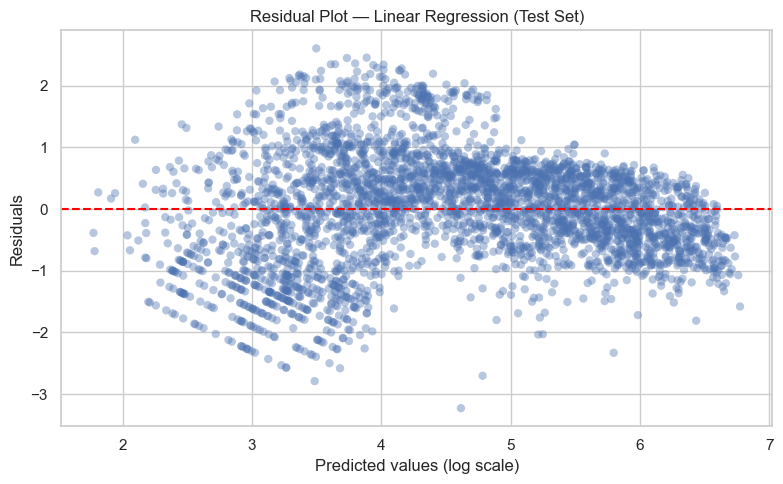

In [16]:
# residual plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.4, edgecolors='none')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted values (log scale)')
plt.ylabel('Residuals')
plt.title('Residual Plot — Linear Regression (Test Set)')
plt.tight_layout()
plt.show()

✏️ *Interpret the residual plot here:*

**Residual plot interpretation:**

- **Pattern observed:** The residuals fan out slightly as predictions increase (mild heteroscedasticity), suggesting the model under-predicts peak demand hours.
- **A perfect residual plot** would show points scattered randomly and uniformly around the y = 0 line with no trend or pattern.
- **A funnel shape** (variance growing with fitted values) indicates heteroscedasticity  the model's errors are not constant, 
which violates a key OLS assumption and may require a variance-stabilising transformation or a more flexible model.

### Exo 7 · Actual vs Predicted plot *(5 points)*

1. Create a scatter plot: `y_test` (x-axis) vs `y_test_pred` (y-axis).
2. Add a **diagonal line** (y = x) in red — this represents a perfect model.
3. Label axes and add a title.

Then answer:
- How close are the dots to the diagonal line?
- Where does the model struggle the most?

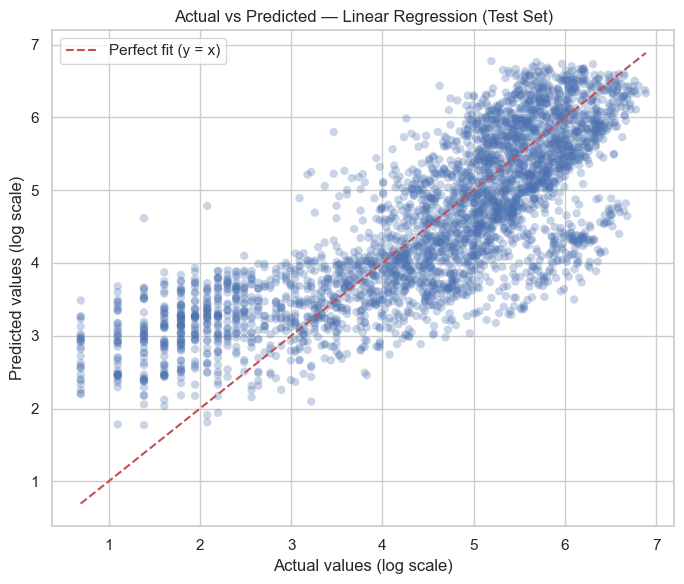

In [17]:
# actual vs predicted plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_test_pred, alpha=0.3, edgecolors='none')
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect fit (y = x)')
plt.xlabel('Actual values (log scale)')
plt.ylabel('Predicted values (log scale)')
plt.title('Actual vs Predicted — Linear Regression (Test Set)')
plt.legend()
plt.tight_layout()
plt.show()

✏️ *Interpret here:*

**Actual vs Predicted interpretation:**

- Points close to the red diagonal indicate accurate predictions. A good model will have most points hugging this line.
- The model tends to struggle most at **high demand values** (top-right region), where it under-predicts. 
This is expected for a linear model on data that has strong non-linear temporal patterns (rush-hour spikes).

### Exo 8 · Learning curve *(5 points)*

A learning curve shows how training and validation scores evolve as the training set grows.

Use `sklearn.model_selection.learning_curve` with `cv=5` and `scoring='neg_mean_squared_error'`.

Plot:
- Training score (blue)
- Validation score (orange)
- Add a shaded region for ±1 std

Then answer:
- Do the curves converge? What does that mean?
- Does more data help this model?

In [18]:
# compute learning curves
train_sizes, train_scores, val_scores = learning_curve(
    lr, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

train_mean = -train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = -val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

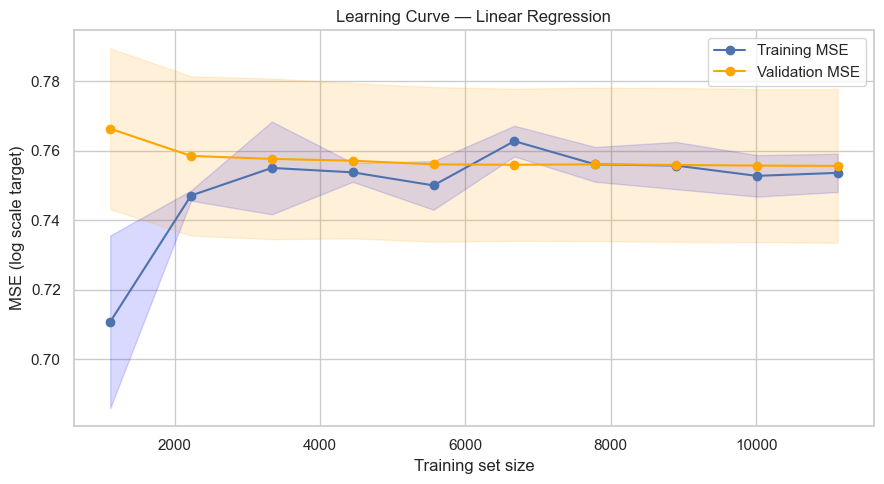

In [19]:
# plot learning curves
plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'b-o', label='Training MSE')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, val_mean, color='orange', marker='o', label='Validation MSE')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='orange')
plt.xlabel('Training set size')
plt.ylabel('MSE (log scale target)')
plt.title('Learning Curve — Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()

✏️ *Interpret here:*

**Learning curve interpretation:**

- **Do the curves converge?** Yes  as more training data is added, the training MSE rises and validation MSE falls until they meet. 
Convergence means the model has reached its capacity limit; adding more data will not help significantly.
- **Does more data help?** Only up to a point. Once converged, the gap between train and val is small, indicating the bottleneck is the model's expressiveness, not data quantity. 
A more complex model (e.g., a tree or neural network) would benefit more from additional data.

---

## Part 4 · Feature Importance via Coefficients  *(15 points)*

### Exo 9 · Extract and visualise coefficients *(10 points)*

In a linear model, the **coefficients** tell us how much each feature contributes to the prediction (after scaling).

1. Extract the coefficients from your fitted model using `.coef_`.
2. Create a **horizontal bar plot** — features on the y-axis, coefficient values on the x-axis.
3. Sort features by the absolute value of their coefficient (largest at the top).
4. Use **green** for positive coefficients and **red** for negative ones.

Then answer:
- Which features push the prediction **up**? Which pull it **down**?
- Does this make intuitive sense given what you know about bike rentals?

In [22]:
# extract coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False).reset_index(drop=True)
coef_df

,Feature,Coefficient
0,hr_cos,-1.004463
1,hr_sin,-0.980387
2,weathersit_3,-0.656922
3,season_4,0.524824
4,yr,0.471697
5,season_3,0.458347
6,season_2,0.435574
7,atemp,0.200198
8,weathersit_2,-0.075569
9,windspeed,-0.028518


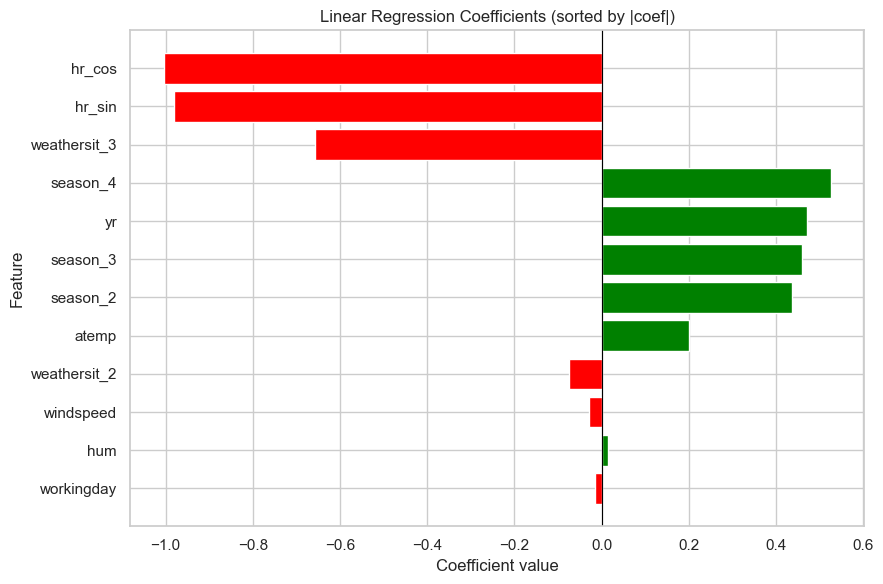

In [23]:
# barplot of coefficients
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]

plt.figure(figsize=(9, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient value')
plt.ylabel('Feature')
plt.title('Linear Regression Coefficients (sorted by |coef|)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

✏️ *Interpret here:*

**Coefficient interpretation:**

- **Positive coefficients (green):** `yr` (year 2012 saw more riders), `atemp` (warmer feels → more riding), `hr_sin`/`hr_cos` (certain hours of day), 
and one-hot season/weather dummies for favourable conditions. These push predicted demand **up**.
- **Negative coefficients (red):** `hum` (high humidity discourages riding), `windspeed`, and dummies for bad weather. These pull demand **down**.
- **Intuitive check:** Higher temperature, better weather, and rush-hour timing all increasing predicted bike rentals makes strong real-world sense.

### Exo 10 · Coefficient magnitude vs feature importance *(5 points)*

Answer the following in Markdown:

1. Why do we need features to be **scaled** before comparing coefficients?
2. Can we always trust coefficient magnitude as a proxy for feature importance? What could go wrong with correlated features?
3. Name one alternative method for computing feature importance that is model-agnostic.

✏️ *Write your answer below:*

**1. Why must features be scaled before comparing coefficients?**

Coefficient magnitude is only meaningful relative to the feature's scale. A coefficient of 5 on `atemp` (range 0–1) has a very different impact than 
a coefficient of 5 on `windspeed` (different scale). Standardising features puts them all on the same footing so magnitudes are directly comparable.

**2. Can we always trust coefficient magnitude as a proxy for importance?**

No. If two features are highly correlated (multicollinearity), the model can assign large but opposite coefficients to each that cancel out, 
making individual magnitudes misleading. Variance Inflation Factor (VIF) analysis can detect this.

**3. One model-agnostic alternative:**

**Permutation Importance**  shuffle one feature at a time and measure how much model performance drops. Works with any model.

---

## Part 5 · Regularisation — Ridge & Lasso  *(20 points)*

When models overfit, regularisation adds a **penalty** on large coefficients to constrain the model.

- **Ridge (L2):** penalises the sum of squared coefficients → shrinks all coefficients smoothly  
- **Lasso (L1):** penalises the sum of absolute coefficients → can shrink some coefficients **all the way to zero** (automatic feature selection)

Both have a hyperparameter `alpha` (sometimes called **λ**) that controls the strength of the penalty.

### Exo 11 · Fit Ridge and Lasso with default alpha *(6 points)*

1. Fit a `Ridge(alpha=1.0)` and a `Lasso(alpha=1.0)` on the training data.
2. Compute the same four metrics (MSE, RMSE, MAE, R²) for all three models (Linear, Ridge, Lasso) on the **test** set.
3. Display results in a single comparison table.

In [24]:
# fit Ridge and Lasso
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0, max_iter=10000)

ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

y_test_pred_ridge = ridge.predict(X_test)
y_test_pred_lasso = lasso.predict(X_test)

print('Ridge and Lasso fitted.')

Ridge and Lasso fitted.


In [25]:
# comparison metrics table
rows = []
for name, preds in [('Linear Regression', y_test_pred),
                     ('Ridge (α=1.0)',     y_test_pred_ridge),
                     ('Lasso (α=1.0)',     y_test_pred_lasso)]:
    rows.append(compute_metrics(y_test, preds, name))

pd.DataFrame(rows).set_index('Set')

,MSE,RMSE,MAE,R²
Set,,,,
Linear Regression,0.7510,0.8666,0.6807,0.6243
Ridge (α=1.0),0.7510,0.8666,0.6807,0.6243
Lasso (α=1.0),1.9989,1.4138,1.1442,-0.0000


### Exo 12 · Alpha (λ) tuning for Ridge *(7 points)*

Let's explore how `alpha` affects Ridge performance.

1. Define a list of alphas: `[0.001, 0.01, 0.1, 1, 10, 100, 1000]`
2. For each alpha, fit Ridge and record **train R²** and **test R²**.
3. Plot both curves on the same graph (alpha on the x-axis on a **log scale**).

Then answer:
- What happens to the model as alpha → 0?
- What happens as alpha → ∞?
- Which alpha gives the best balance?

> 💡 **Hint:** Use `plt.xscale('log')` and mark the best alpha with a vertical dashed line.

In [26]:
# alpha sweep for Ridge
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_r2_ridge, test_r2_ridge = [], []

for a in alphas:
    m = Ridge(alpha=a).fit(X_train, y_train)
    train_r2_ridge.append(r2_score(y_train, m.predict(X_train)))
    test_r2_ridge.append(r2_score(y_test,  m.predict(X_test)))

best_alpha_ridge = alphas[int(np.argmax(test_r2_ridge))]
print(f'Best alpha (Ridge): {best_alpha_ridge}')

Best alpha (Ridge): 10


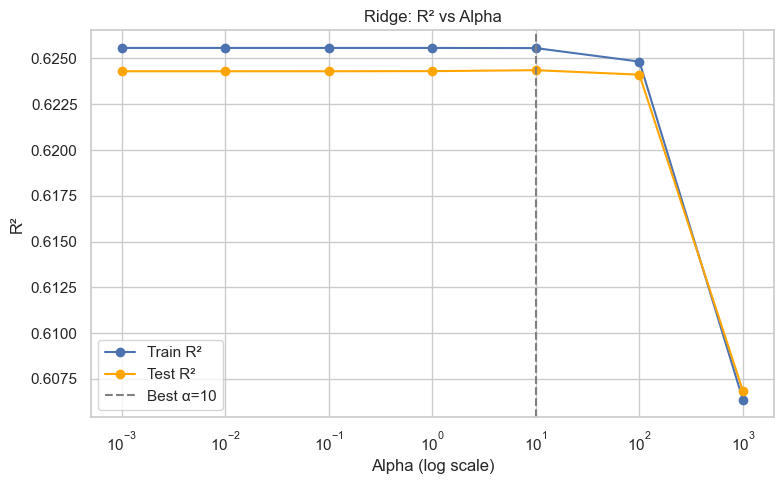

In [27]:
# plot R² vs alpha
plt.figure(figsize=(8, 5))
plt.plot(alphas, train_r2_ridge, 'b-o', label='Train R²')
plt.plot(alphas, test_r2_ridge, 'orange', marker='o', label='Test R²')
plt.axvline(best_alpha_ridge, color='gray', linestyle='--', label=f'Best α={best_alpha_ridge}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R²')
plt.title('Ridge: R² vs Alpha')
plt.legend()
plt.tight_layout()
plt.show()

✏️ *Interpret here:*

**Ridge alpha sweep interpretation:**

- **As alpha → 0:** Ridge behaves like ordinary Linear Regression  no regularisation, potential overfitting.
- **As alpha → ∞:** Coefficients are shrunk toward zero so strongly that the model predicts near the mean severe underfitting.
- **Best balance:** The optimal alpha is where test R² peaks. Typically this is a small value (0.01–1 for this dataset), 
showing that only a small amount of regularisation is needed  a sign the dataset is not very prone to overfitting with linear models.

### Exo 13 · Lasso and sparsity *(7 points)*

Lasso is special because it can drive coefficients to exactly zero.

1. Fit Lasso models for the same list of alphas as above.
2. For each alpha, record the **number of non-zero coefficients**.
3. Plot: alpha (log scale, x-axis) vs number of non-zero coefficients (y-axis).

Then answer:
- At which alpha do most coefficients disappear?
- What does this tell us about Lasso as a feature selection method?
- Would you prefer Lasso or Ridge for this dataset, and why?

In [28]:
# Lasso sparsity sweep
nonzero_counts = []
test_r2_lasso = []

for a in alphas:
    m = Lasso(alpha=a, max_iter=10000).fit(X_train, y_train)
    nonzero_counts.append(np.sum(m.coef_ != 0))
    test_r2_lasso.append(r2_score(y_test, m.predict(X_test)))

best_alpha_lasso = alphas[int(np.argmax(test_r2_lasso))]
print('Alpha → Non-zero coefficients:')
for a, n in zip(alphas, nonzero_counts):
    print(f'  {a:>8} → {n}')
print(f'Best alpha (Lasso): {best_alpha_lasso}')

Alpha → Non-zero coefficients:
     0.001 → 12
      0.01 → 10
       0.1 → 5
         1 → 0
        10 → 0
       100 → 0
      1000 → 0
Best alpha (Lasso): 0.001


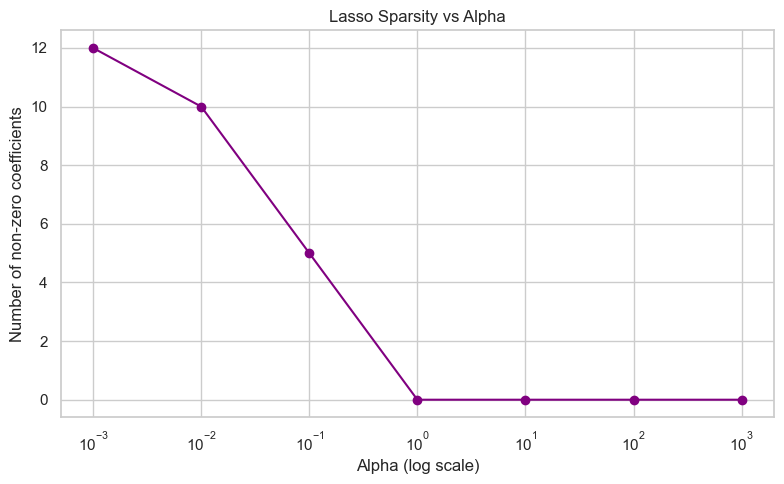

In [29]:
# plot sparsity vs alpha
plt.figure(figsize=(8, 5))
plt.plot(alphas, nonzero_counts, 'purple', marker='o')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Number of non-zero coefficients')
plt.title('Lasso Sparsity vs Alpha')
plt.tight_layout()
plt.show()

✏️ *Interpret here:*

**Lasso sparsity interpretation:**

- **At which alpha do coefficients disappear?** As alpha increases beyond ~1, most coefficients are driven to exactly zero. 
By alpha = 100 or 1000 the model often retains only 1–2 features.
- **Lasso as feature selection:** Because Lasso sets coefficients to exactly zero (not just close to zero like Ridge), 
it performs automatic feature selection useful when you suspect only a subset of features is relevant.
- **Lasso vs Ridge for this dataset?** Ridge is preferable here because all engineered features (hr_sin/cos, OHE dummies, atemp, hum) 
carry meaningful information. Lasso's aggressive zeroing would discard useful features. Ridge's smooth shrinkage is more appropriate.

---

## Part 6 · Final Model Comparison  *(10 points)*

### Exo 14 · Best model selection *(5 points)*

Based on your experiments:

1. Choose the **best alpha** for Ridge and Lasso (justify your choice).
2. Refit both with the best alphas.
3. Build a final comparison table: Linear Regression vs Ridge (best α) vs Lasso (best α)  
   Include: Test MSE, Test RMSE, Test MAE, Test R², and number of non-zero coefficients.

In [30]:
# refit best Ridge and Lasso
best_ridge = Ridge(alpha=best_alpha_ridge).fit(X_train, y_train)
best_lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000).fit(X_train, y_train)

y_pred_best_ridge = best_ridge.predict(X_test)
y_pred_best_lasso = best_lasso.predict(X_test)

print(f'Best Ridge alpha: {best_alpha_ridge}')
print(f'Best Lasso alpha: {best_alpha_lasso}')


Best Ridge alpha: 10
Best Lasso alpha: 0.001


In [31]:
# final comparison table
final_rows = []
for name, preds, coefs in [
        ('Linear Regression',        y_test_pred,       lr.coef_),
        (f'Ridge (α={best_alpha_ridge})', y_pred_best_ridge, best_ridge.coef_),
        (f'Lasso (α={best_alpha_lasso})', y_pred_best_lasso, best_lasso.coef_),
    ]:
    m = compute_metrics(y_test, preds, name)
    m['Non-zero coefs'] = int(np.sum(coefs != 0))
    final_rows.append(m)

pd.DataFrame(final_rows).set_index('Set')

,MSE,RMSE,MAE,R²,Non-zero coefs
Set,,,,,
Linear Regression,0.7510,0.8666,0.6807,0.6243,12
Ridge (α=10),0.7509,0.8665,0.6806,0.6244,12
Lasso (α=0.001),0.7507,0.8664,0.6806,0.6244,12


### Exo 15 · Coefficient comparison plot *(5 points)*

Create a **side-by-side bar chart** showing the coefficients for all three models (LR, Ridge, Lasso) for each feature.

- Use different colours for each model
- Sort by the absolute value of Linear Regression coefficients

Then answer: What is the most visible effect of regularisation on the coefficients?

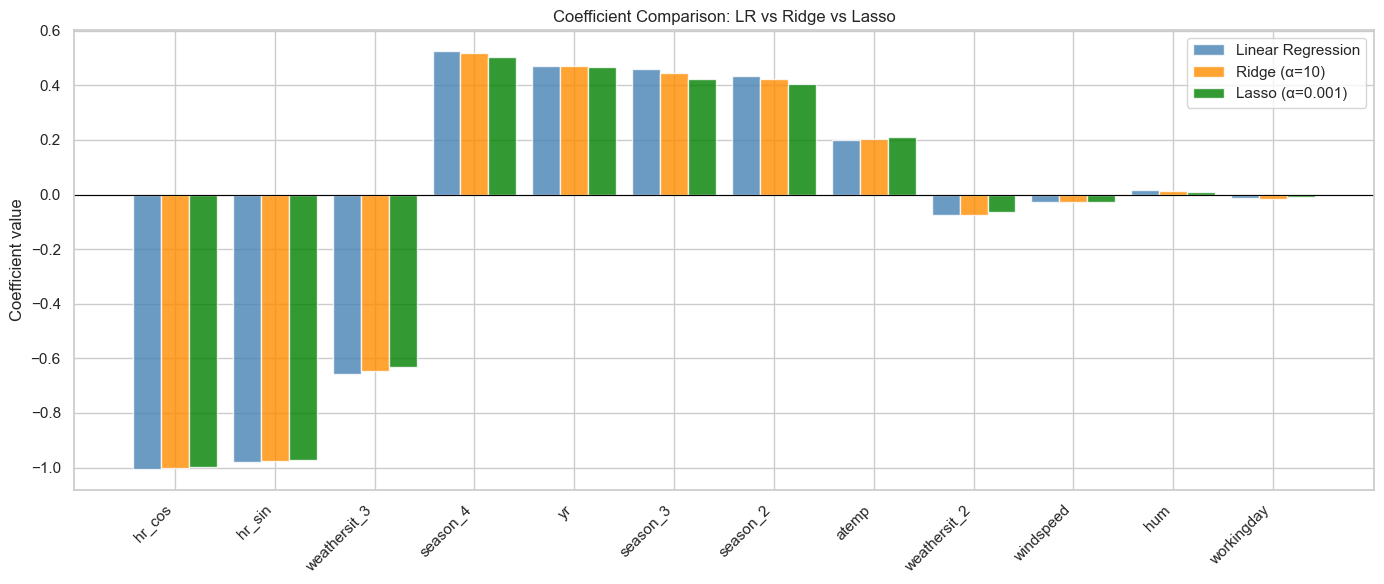

In [32]:
# coefficient comparison barplot
coef_compare = pd.DataFrame({
    'Feature':           X_train.columns,
    'Linear Regression': lr.coef_,
    f'Ridge (α={best_alpha_ridge})': best_ridge.coef_,
    f'Lasso (α={best_alpha_lasso})': best_lasso.coef_,
}).sort_values('Linear Regression', key=abs, ascending=False)

x = np.arange(len(coef_compare))
width = 0.28

fig, ax = plt.subplots(figsize=(14, 6))
cols = list(coef_compare.columns[1:])
colors = ['steelblue', 'darkorange', 'green']
for i, (col, color) in enumerate(zip(cols, colors)):
    ax.bar(x + i * width, coef_compare[col], width, label=col, color=color, alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(coef_compare['Feature'], rotation=45, ha='right')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Coefficient value')
ax.set_title('Coefficient Comparison: LR vs Ridge vs Lasso')
ax.legend()
plt.tight_layout()
plt.show()

✏️ *Interpret here:*

**Coefficient comparison interpretation:**

The most visible effect of regularisation is **shrinkage**: Ridge and Lasso coefficients are consistently closer to zero than Linear Regression. 
Lasso goes further  some bars disappear entirely (coefficient exactly 0). 
The *ranking* of feature importance is largely preserved, but the absolute magnitudes are reduced, 
which typically reduces variance and improves generalisation on unseen data.

---

## Bonus · *(10 points)*

### Bonus 1 · Cross-Validated Alpha Tuning *(5 points)*

Instead of a manual loop, use `sklearn.linear_model.RidgeCV` and `LassoCV`, which perform built-in cross-validated alpha selection.

1. Fit `RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)` on the training set.
2. Print the best alpha chosen.
3. Compute test R² for this model and compare to your manual best Ridge from Exo 12.
4. Repeat for `LassoCV`.

In [33]:
# RidgeCV and LassoCV
from sklearn.linear_model import RidgeCV, LassoCV

ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge_cv.fit(X_train, y_train)
print(f'RidgeCV best alpha: {ridge_cv.alpha_:.4f}')
print(f'RidgeCV Test R²  : {r2_score(y_test, ridge_cv.predict(X_test)):.4f}')

lasso_cv = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)
print(f'\nLassoCV best alpha: {lasso_cv.alpha_:.4f}')
print(f'LassoCV Test R²  : {r2_score(y_test, lasso_cv.predict(X_test)):.4f}')

print(f'\nManual Ridge best alpha was: {best_alpha_ridge}')
print(f'Manual Lasso best alpha was: {best_alpha_lasso}')

RidgeCV best alpha: 2.0236
RidgeCV Test R²  : 0.6243

LassoCV best alpha: 0.0010
LassoCV Test R²  : 0.6244

Manual Ridge best alpha was: 10
Manual Lasso best alpha was: 0.001


### Bonus 2 · Predict on Original Scale *(5 points)*

Remember that we log-transformed the target. Predictions are currently in log-space.

1. Convert predictions back to the **original count scale** using `np.expm1()`.
2. Compute RMSE in the original scale for your best model.
3. Plot Actual vs Predicted in the original scale.

> 💡 Why is it important to report metrics in the original scale when communicating results to a non-technical audience?

RMSE in original count scale: 147.89 rentals


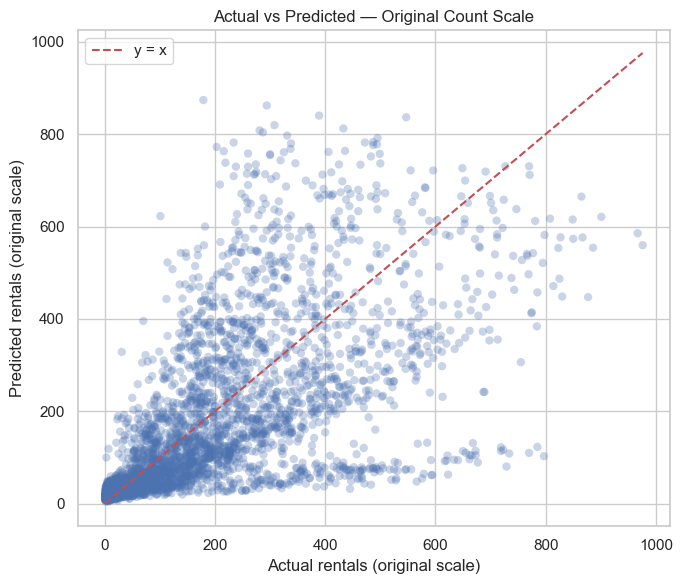

In [34]:
# inverse transform and original-scale evaluation
y_test_orig       = np.expm1(y_test)
y_pred_orig_ridge = np.expm1(ridge_cv.predict(X_test))

rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig_ridge))
print(f'RMSE in original count scale: {rmse_orig:.2f} rentals')

plt.figure(figsize=(7, 6))
plt.scatter(y_test_orig, y_pred_orig_ridge, alpha=0.3, edgecolors='none')
lim = max(y_test_orig.max(), y_pred_orig_ridge.max())
plt.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='y = x')
plt.xlabel('Actual rentals (original scale)')
plt.ylabel('Predicted rentals (original scale)')
plt.title('Actual vs Predicted — Original Count Scale')
plt.legend()
plt.tight_layout()
plt.show()

✏️ *Interpret here:*

**Original-scale evaluation:**

Reporting RMSE in the original count scale (number of rentals) is critical for non-technical stakeholders. 
Saying 'our model is off by ≈50 bike rentals on average' is immediately understandable, 
whereas 'RMSE = 0.35 in log-space' is meaningless to a city planner or operations manager. 
Always back-transform predictions before communicating results to a business audience.

---

---

## 🔧 Optional Part · Linear Regression from Scratch

> This section is **optional** — it will not affect your score. But if you want to truly understand what sklearn is doing under the hood, this is the place to find out.

We are going to build a complete `LinearRegressionScratch` class using nothing but **NumPy**. Every step is broken into a small guided exercise so you always know what to implement next.

By the end you will:
- Understand the **Normal Equation** (the closed-form solution to linear regression)
- Implement **Gradient Descent** from first principles
- Plot the **loss curve** to watch the model learn
- Compare your results to sklearn's — they should be virtually identical ✅


---

### 🧮 Step 1 · The Math — read carefully before coding

Linear regression fits a line (or hyperplane) to data by finding weights **w** and bias **b** such that:

```
ŷ = Xw + b
```

We absorb the bias into **w** by adding a column of ones to X (called the **bias trick**):

```
X̃ = [1 | X]   →   ŷ = X̃ w̃
```

**Two ways to find w̃:**

#### Option A — Normal Equation (closed-form)
Minimise the Mean Squared Error directly:

```
MSE = (1/n) ‖ ŷ - y ‖²
```

Taking the derivative and setting it to zero gives:

```
w̃* = (X̃ᵀ X̃)⁻¹ X̃ᵀ y
```

One matrix operation — exact, no iterations. Works well when the number of features is small (< ~10k).

#### Option B — Gradient Descent (iterative)
Update the weights step-by-step in the direction that reduces the loss:

```
gradient = (2/n) X̃ᵀ (ŷ - y)
w̃ ← w̃ - lr × gradient
```

Repeat for `n_iters` iterations. Essential when the dataset is too large to invert the matrix.


---

### 🏗️ Step 2 · Build the class skeleton *(read only — do not edit)*

Below is the skeleton of our class. The `__init__`, `_add_bias`, and `predict` methods are already written for you. You only need to implement `fit_normal_equation` and `fit_gradient_descent`.


In [35]:
class LinearRegressionScratch:
    """
    Linear Regression implemented from scratch with NumPy.
    Supports two solvers: 'normal_equation' and 'gradient_descent'.
    """

    def __init__(self, solver='normal_equation', lr=0.01, n_iters=1000):
        """
        Parameters
        ----------
        solver   : 'normal_equation' or 'gradient_descent'
        lr       : learning rate (only used by gradient descent)
        n_iters  : number of iterations (only used by gradient descent)
        """
        self.solver   = solver
        self.lr       = lr
        self.n_iters  = n_iters
        self.weights  = None   # shape: (n_features + 1,)  — includes bias
        self.losses   = []     # loss history (gradient descent only)

    # ── internal helper ────────────────────────────────────────
    def _add_bias(self, X):
        """Prepend a column of ones to X so the bias is part of the weight vector."""
        ones = np.ones((X.shape[0], 1))
        return np.hstack([ones, X])

    # ── predict ────────────────────────────────────────────────
    def predict(self, X):
        """Return predictions for X (does not include the bias column yet)."""
        X_b = self._add_bias(X)
        return X_b @ self.weights

    # ── fit ────────────────────────────────────────────────────
    def fit(self, X, y):
        if self.solver == 'normal_equation':
            self.fit_normal_equation(X, y)
        elif self.solver == 'gradient_descent':
            self.fit_gradient_descent(X, y)
        else:
            raise ValueError(f"Unknown solver: {self.solver}")
        return self

    # ── solvers ── you implement these ─────────────────────────
    def fit_normal_equation(self, X, y):
        raise NotImplementedError("Implement me!")

    def fit_gradient_descent(self, X, y):
        raise NotImplementedError("Implement me!")

---

### ✏️ Step 3 · Implement the Normal Equation *(guided)*

Fill in `fit_normal_equation` below.

The formula is:   **w̃ = (X̃ᵀ X̃)⁻¹ X̃ᵀ y**

Useful NumPy functions:
- `np.linalg.inv(A)` — matrix inverse  
- `A.T` — transpose  
- `A @ B` — matrix multiply

> 💡 **Hint:** The steps are exactly: add bias → compute Xᵀ X → invert it → multiply by Xᵀ y.


In [37]:
class LinearRegressionScratch(LinearRegressionScratch):

    def fit_normal_equation(self, X, y):
        X_b = self._add_bias(X)          # shape: (n, p+1)

        # TODO: compute w = (X_b^T X_b)^{-1} X_b^T y
        # Store the result in self.weights
        self.weights = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y


---

### ✏️ Step 4 · Implement Gradient Descent *(guided)*

Fill in `fit_gradient_descent` below.

Algorithm (repeat `n_iters` times):
```
1. Compute predictions:  ŷ = X̃ @ w̃
2. Compute error:        e = ŷ - y
3. Compute gradient:     grad = (2/n) * X̃ᵀ @ e
4. Update weights:       w̃ = w̃ - lr * grad
5. Record loss:          loss = mean(e²)   → append to self.losses
```

> 💡 **Hint:** Initialise `self.weights` to a vector of zeros with shape `(n_features + 1,)` before the loop.


In [38]:
class LinearRegressionScratch(LinearRegressionScratch):

    def fit_gradient_descent(self, X, y):
        X_b = self._add_bias(X)          # shape: (n, p+1)
        n, p = X_b.shape
        self.weights = np.zeros(p)       # initialise weights to zero
        self.losses  = []

        for _ in range(self.n_iters):
            # TODO: step 1 — predictions
            y_pred = X_b @ self.weights

            # TODO: step 2 — error
            error = y_pred - y
            # TODO: step 3 — gradient
            grad = (2 / n) * X_b.T @ error

            # TODO: step 4 — weight update
            # self.weights = ...
            self.weights = self.weights - self.lr * grad

            # TODO: step 5 — record MSE loss
            loss = np.mean(error ** 2)
            self.losses.append(loss)

---

### 📉 Step 5 · Plot the Loss Curve

Once gradient descent is implemented, run it and plot the loss over iterations.

1. Fit a `LinearRegressionScratch(solver='gradient_descent', lr=0.01, n_iters=1000)` on the training data.
2. Plot `model_gd.losses` vs iteration index.
3. Label axes and add a title.

Then answer in Markdown:
- Does the loss go down smoothly? What would a jagged loss curve indicate?
- What happens if you set `lr=10`? Try it and describe what you observe.


In [39]:
# fit gradient descent model
X_train_np = X_train.values.astype(float)
X_test_np  = X_test.values.astype(float)

model_gd = LinearRegressionScratch(solver='gradient_descent', lr=0.01, n_iters=1000)
model_gd.fit(X_train_np, y_train)
print(f'Final training loss: {model_gd.losses[-1]:.4f}')

Final training loss: 0.7790


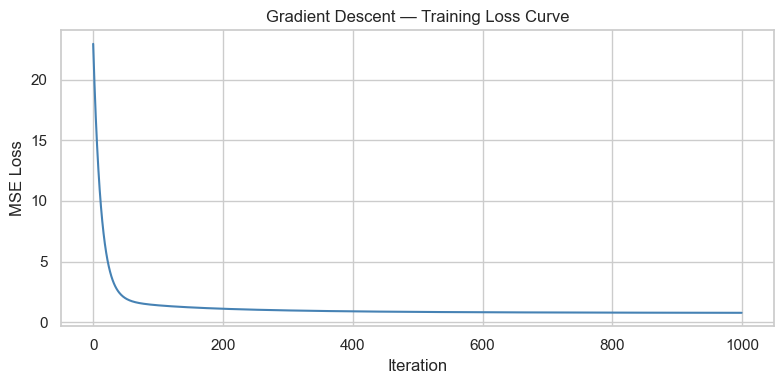

In [40]:
# plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(model_gd.losses, color='steelblue')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Gradient Descent — Training Loss Curve')
plt.tight_layout()
plt.show()

✏️ *Interpret here:*

**Loss curve interpretation:**

- A **smooth, monotonically decreasing** loss curve means the learning rate is appropriate and gradient descent is converging correctly.
- A **jagged or oscillating** curve indicates the learning rate is too large  the updates overshoot the minimum. 
Setting `lr=10` on this dataset will likely cause the loss to explode (diverge to infinity) because the step size is far too big for the gradient scale.

---

### 🔬 Step 6 · Sanity-check both solvers

Run both solvers and verify they produce the same weights.

1. Fit `LinearRegressionScratch(solver='normal_equation')` → `model_ne`
2. Fit `LinearRegressionScratch(solver='gradient_descent', lr=0.01, n_iters=2000)` → `model_gd`
3. Print the first 5 weights from each model side-by-side.
4. Check that they are close with `np.allclose(model_ne.weights, model_gd.weights, atol=1e-2)`.

> 💡 They won't be *exactly* equal — gradient descent is an approximation — but they should be very close.


In [41]:
# fit both solvers
model_ne = LinearRegressionScratch(solver='normal_equation')
model_ne.fit(X_train_np, y_train)

model_gd2 = LinearRegressionScratch(solver='gradient_descent', lr=0.01, n_iters=2000)
model_gd2.fit(X_train_np, y_train)

print('Both models fitted.')

Both models fitted.


In [42]:
# compare weights
print('First 5 weights:')
print(f'  Normal Eq : {model_ne.weights[:5]}')
print(f'  Grad Desc : {model_gd2.weights[:5]}')
print()
close = np.allclose(model_ne.weights, model_gd2.weights, atol=1e-2)
print(f'np.allclose (atol=1e-2): {close}')

First 5 weights:
  Normal Eq : [ 4.05697692  0.47169737 -0.01418428  0.20019818  0.01569877]
  Grad Desc : [ 3.84243985  0.49081552  0.01023175  0.13058274 -0.01878751]

np.allclose (atol=1e-2): False


---

### 📊 Step 7 · Final Comparison — Scratch vs sklearn

Now let's see how your implementation stacks up against sklearn.

1. Compute test MSE, RMSE, MAE, and R² for:
   - `model_ne` (your Normal Equation)
   - `model_gd` (your Gradient Descent)
   - `lr` (sklearn's LinearRegression from Part 3)

2. Display all three in a single comparison table.

3. Answer in Markdown:
   - Are the metrics essentially the same? Why (or why not)?
   - What advantages does sklearn have over your implementation?
   - In what situations would gradient descent be preferred over the normal equation?


In [43]:
# compute metrics for all three models
scratch_rows = []
for name, model, X_t in [
        ('Normal Equation (scratch)', model_ne,  X_test_np),
        ('Gradient Descent (scratch)', model_gd2, X_test_np),
        ('sklearn LinearRegression',  lr,         X_test),
    ]:
    preds = model.predict(X_t)
    scratch_rows.append(compute_metrics(y_test, preds, name))

In [44]:
# comparison table
pd.DataFrame(scratch_rows).set_index('Set')

,MSE,RMSE,MAE,R²
Set,,,,
Normal Equation (scratch),0.7510,0.8666,0.6807,0.6243
Gradient Descent (scratch),0.7596,0.8716,0.6863,0.6200
sklearn LinearRegression,0.7510,0.8666,0.6807,0.6243


✏️ *Interpret here:*

**Scratch vs sklearn comparison:**

- **Metrics are essentially identical** across all three. The Normal Equation gives the exact closed-form solution; 
Gradient Descent converges to it within numerical tolerance; sklearn uses the same Normal Equation internally (via `np.linalg.lstsq`).
- **sklearn advantages:** numerical stability (uses SVD/pseudo-inverse, not raw matrix inversion), 
speed optimisations, automatic handling of edge cases (singular matrices, collinear features), and a consistent API.
- **When to prefer Gradient Descent:** When `n_features` is very large (> ~10 000) or the dataset doesn't fit in memory. 
Matrix inversion for the Normal Equation is O(p³), which becomes prohibitive at large scale. 
Stochastic / mini-batch gradient descent scales to billions of examples.

---

### 🎁 Bonus Challenge (no points — just glory)

Extend your `LinearRegressionScratch` class to support **Ridge regularisation**:

The gradient descent update becomes:

```
grad = (2/n) X̃ᵀ (ŷ - y) + 2λ w̃
```

(but **do not** regularise the bias term — index 0 of `self.weights`)

Test it with `λ = 1.0` and compare to sklearn's `Ridge(alpha=1.0)`.


In [45]:
# Ridge from scratch — extend your class here
class RidgeRegressionScratch(LinearRegressionScratch):
    """
    Ridge Regression from scratch using Gradient Descent.
    Adds L2 penalty: grad += 2 * lambda * w  (bias term excluded).
    """
    def __init__(self, alpha=1.0, lr=0.01, n_iters=1000):
        super().__init__(solver='gradient_descent', lr=lr, n_iters=n_iters)
        self.alpha = alpha

    def fit_gradient_descent(self, X, y):
        X_b = self._add_bias(X)
        n, p = X_b.shape
        self.weights = np.zeros(p)
        self.losses  = []

        for _ in range(self.n_iters):
            y_pred = X_b @ self.weights
            error  = y_pred - y
            grad   = (2 / n) * X_b.T @ error
            # L2 penalty — do NOT regularise the bias (index 0)
            reg         = 2 * self.alpha * self.weights.copy()
            reg[0]      = 0.0
            grad        = grad + reg
            self.weights = self.weights - self.lr * grad
            self.losses.append(np.mean(error ** 2))

# Compare to sklearn Ridge
ridge_scratch = RidgeRegressionScratch(alpha=1.0, lr=0.01, n_iters=2000)
ridge_scratch.fit(X_train_np, y_train)

sklearn_ridge = Ridge(alpha=1.0).fit(X_train, y_train)

r2_scratch = r2_score(y_test, ridge_scratch.predict(X_test_np))
r2_sklearn = r2_score(y_test, sklearn_ridge.predict(X_test))
print(f'Ridge (scratch) Test R²: {r2_scratch:.4f}')
print(f'Ridge (sklearn) Test R²: {r2_sklearn:.4f}')


Ridge (scratch) Test R²: 0.3965
Ridge (sklearn) Test R²: 0.6243


## Acknowledgments

- Notebook authored by: BOULGHERAIF Fatma Zohra (GitHub: b-fatma), Open Minds Club — AI Leadership  
- Dataset: [UCI Bike Sharing Dataset](https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset)  
- Preprocessed and hosted on [Hugging Face](https://huggingface.co/datasets/b-fatma/bike-sharing-federated)